# Cavity blockade: a way to make photons interact

## Importing libraries

In [275]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import seaborn as sns
#from IPython.display import HTML

In this exercise you will explore a regime in which a cavity, once filled with a single photon, blocks the possibility to insert another one. This can be effectively interpreted as a photon-photon interaction mediated by the atom in the cavity, a possibility that photons in vacuum do not have (the photon-photon cross section predicted by QED in vacuum is extremely small). The first observation of this phenomenon was done in Birnbaum et al. Nature 436, 87 (2005).

A driven cavity is described by a Jaynes-Cummings model:
$$
    \hat{H} = \hbar \omega_c \hat{a}^\dagger \hat{a} + \hbar \omega_a |e\rangle\langle e| + \hbar \tilde{g}(\hat{\sigma}_+ \hat{a} + \hat{\sigma}_- \hat{a}^\dagger) + \hat{H}_d,
$$
where $\hat{H}_d = \mathcal{E} e^{i \omega t} \hat{a} + \text{h.c.}$ is a (pumping) driving field.


## 1. Explain the physical meaning of $H_d$. How would you realize such a term?


The physical meaning of $H_d$ is that of a coherent driving field that pumps the cavity mode at frequency $\omega$. This term represents the interaction between the cavity field and an external classical field, which can be realized experimentally by shining a laser beam into the cavity. The laser frequency $\omega$ is typically chosen to be close to the cavity resonance frequency $\omega_c$ to efficiently drive the cavity mode. The amplitude $\mathcal{E}$ characterizes the strength of the driving field, which can be controlled by adjusting the intensity of the laser.

## 2. Rewrite the hamiltonian in the frame of the drive and use the RWA.

Consider $\omega = \omega_a = \omega_c$ and no coupling between cavity and atom, $\tilde{g} = 0$. Given an initially empty cavity, $|g, 0\rangle$, you will numerically solve the corresponding master equation at resonance (you can use the QuTiP library). Assume a small decay rate of the atom in the photon modes outside the cavity, $\Gamma$, and assume also that the cavity is not perfect and can lose photons with a small decay rate $\kappa$.


### A. Initial Hamiltonian ($\hat{H}$)
The system starts with the Hamiltonian in the laboratory frame, including the cavity field, a two-level atom, the atom-cavity interaction, and an external pumping field:

$$\hat{H} = \hbar \omega_c a^\dagger a + \hbar \omega_a |e\rangle \langle e| + \hbar \tilde{g} (\sigma^+ a + \sigma^- a^\dagger) + \varepsilon e^{i\omega t} a + \varepsilon^* e^{-i\omega t} a^\dagger$$

**Parameters:**
* $\omega = \omega_c = \omega_a$ (Resonant condition for the pumping field frame).
* $\delta \approx 0$ and $\omega \gg \delta$.

---

### B. Unitary Transformation ($R$)
To move to the rotating frame, we define the unitary operator $R$ as a tensor product of the atomic and electromagnetic (EM) field rotations:

$$R = e^{i\omega |e\rangle \langle e| t} \otimes e^{i\omega a^\dagger a t} = R_A \otimes R_{EM}$$

The transformed Hamiltonian $H'$ is calculated using the formula:
$$H' = R H R^\dagger - i\hbar R \dot{R}^\dagger$$

---

### C. Expanding the Transformation Terms

#### Part I: The Inertial Term ($-i\hbar R \dot{R}^\dagger$)
Using the identities for the time derivatives of the unitary operators:
* $R_A \dot{R}_A^\dagger = -i\omega |e\rangle \langle e|$
* $R_{EM} \dot{R}_{EM}^\dagger = -i\omega a^\dagger a$

The full term simplifies to:
$$-i\hbar R \dot{R}^\dagger = -\hbar \omega a^\dagger a - \hbar \omega |e\rangle \langle e|$$

#### Part II: Transforming the Operators ($R H R^\dagger$)
We apply the transformation $R$ to each term of the original Hamiltonian. Note that $a_H(t) = R_{EM} a R_{EM}^\dagger = a e^{-i\omega t}$ and $\sigma_H(t) = \sigma e^{-i\omega t}$.

1. **Cavity Energy:**
   $$1 \otimes R_{EM} \hbar \omega_c a^\dagger a R_{EM}^\dagger = \hbar \omega_c a^\dagger a$$
2. **Atomic Energy:**
   $$R_A \hbar \omega_a |e\rangle \langle e| R_A^\dagger \otimes 1 = \hbar \omega_a |e\rangle \langle e|$$
3. **Interaction Terms:**
   $$R_A \sigma^+ R_A^\dagger \otimes R_{EM} a R_{EM}^\dagger = \sigma^+ e^{i\omega t} \otimes a e^{-i\omega t} = \sigma^+ a$$
   $$R_A \sigma^- R_A^\dagger \otimes R_{EM} a^\dagger R_{EM}^\dagger = \sigma^- e^{-i\omega t} \otimes a^\dagger e^{i\omega t} = \sigma^- a^\dagger$$

4. **Pumping Field Terms:**
   $$\varepsilon e^{i\omega t} a_H = \varepsilon a$$
   $$\varepsilon^* e^{-i\omega t} a_H^\dagger = \varepsilon^* a^\dagger$$

---

### D. Final Transformed Hamiltonian ($H'$)
Combining the results and defining detunings $\delta_c = \omega_c - \omega$ and $\delta_a = \omega_a - \omega$:

$$
 H' = \hbar \delta_c a^\dagger a + \hbar \delta_a |e\rangle \langle e| + \hbar g (\sigma^+ a_H(0) + \sigma^- a_H^\dagger (0) ) + \xi (a_H(0) +  a_H^\dagger(0))
 $$ 
LAB FRAME:

$$
 H' = \hbar \omega_c a^\dagger a + \hbar \omega_a |e\rangle \langle e| + \hbar g (\sigma^+ a_H(0) + \sigma^- a_H^\dagger (0)  + \xi( a_H(0) +  a_H^\dagger(0) )
 $$ 

The lindblard master equation of this system is:

$$
\dot{\rho} = i \hbar [H',\rho] + 
$$

In [ ]:
#Define operators
hbar=1
N = 20  # number of cavity fock states
wc = 1.0 * 2 * np.pi  # cavity frequency
wa = 1 * 2 * np.pi  # atom frequency
w = 1* 2 * np.pi  # drive frequency
E = 0.0005  # Drive amplitude
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
n_th_a = 0  # temperature in frequency units

tlist = np.linspace(0, 20000 , 2000) 
# intial state
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 0)) # cavity vacuum and atom ground state

# Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2)) # cavity annihilation operator
sm = qt.tensor(qt.qeye(N), qt.destroy(2)) # atom lowering operator

Now let's define the Hamiltonian we will use in the simulation:

In [277]:


not_coupling = True # turn off/on coupling 





da = wa-w
dc = wc-w

if not_coupling:
    g=0
    da=0
    dc=0




Ht_0 = E*(a.dag() + a)
#hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)

# Collapse operators

# This operators are useful to model the dissipation in the system
c_op_list = []

# Photon annihilation
rate = kappa * (1 + n_th_a)
c_op_list.append(np.sqrt(rate) * a)

# Photon creation
#rate = E * n_th_a
#c_op_list.append(np.sqrt(rate) * a.dag())

# Atom annihilation
rate = gamma
c_op_list.append(np.sqrt(rate) * sm)

output = qt.mesolve(Ht_0, psi0, tlist, c_op_list, e_ops =[a.dag() * a, sm.dag() * sm, a.dag() * a.dag() * a* a], options={"store_states": True, "nsteps": 10000, "atol": 1e-8, "rtol": 1e-6})



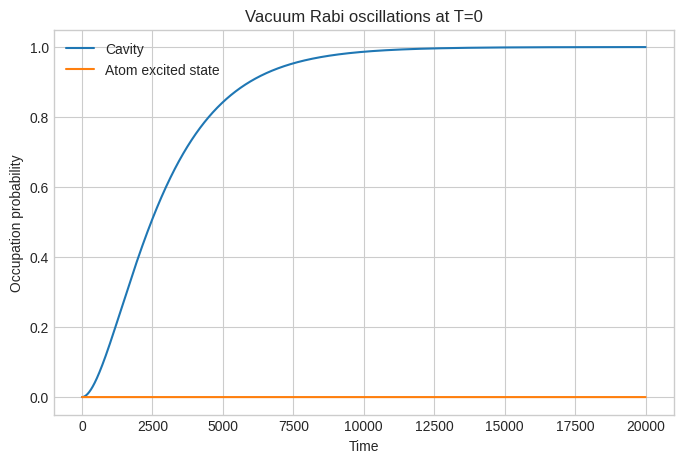

In [278]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tlist, output.expect[0], label="Cavity")
ax.plot(tlist, output.expect[1], label="Atom excited state")
ax.legend()
ax.set_xlabel("Time")
ax.set_ylabel("Occupation probability")
ax.set_title("Vacuum Rabi oscillations at T={}".format(n_th_a));

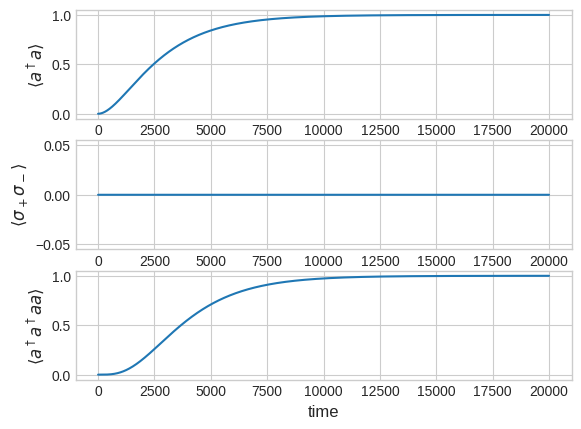

In [279]:
qt.plot_expectation_values(output, ylabels=[r"$\langle a^\dagger a \rangle$", r"$\langle \sigma_+ \sigma_- \rangle$",r"$\langle a^\dagger a^\dagger a a\rangle$"]);

```python
for n, o in enumerate([r"$\langle a^\dagger a \rangle$", r"$\langle \sigma_+ \sigma_- \rangle$",r"$\langle a^\dagger a^\dagger a a\rangle$"])
    plt.plot(tlist, output.expect[n], label=o)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Expected values over time")
    plt.legend()
    plt.grid(True)
```

Now we can define the density matrix evolution for the cavity and the atom seeparately.

In [280]:
# Select a specific time index from your simulation (e.g., the last state)
final_state = output.final_state
states_ev = output.states
# Since your state is a tensor product (Cavity + Atom), 
# we must trace out the atom to see only the cavity.
rho_cavity_final = qt.ptrace(final_state, 0)
rho_atom_final = qt.ptrace(final_state, 1)

rho_cavity_ev = [qt.ptrace(state, 0) for state in states_ev]
rho_atom_ev = [qt.ptrace(state, 1) for state in states_ev]



In [281]:
#fig, ani = qt.anim_matrix_histogram(rho_atom_ev, limits=[0, 1],
#                                 bar_style='abs', color_style='phase')
# close an auto-generated plot and animation
#plt.close()
#ani

In [282]:
#fig, ani = qt.anim_matrix_histogram(rho_cavity_ev, limits=[0, 1],
#                                 bar_style='abs', color_style='phase')
# close an auto-generated plot and animation
#plt.close()
#ani

In [283]:
#ani.save('atom_excited_state_animation.mp4', fps=30, dpi=200)
#ani.save('cavity_excited_state_animation.mp4', fps=30, dpi=200)

```python
# Calculate Wigner function
xvec = np.linspace(-5, 5, 200)
W = qt.wigner(rho_cavity, xvec, xvec)

# Plotting
fig, ax = plt.subplots()
cont = ax.contourf(xvec, xvec, W, 100, cmap='RdBu')
ax.set_title("Wigner Function of the Cavity")
plt.colorbar(cont)
plt.show()
```

```python 

# Initialize Bloch sphere
b = qt.Bloch()

# You can add a single point (the current state)
b.add_states(rho_atom_final)

# Or add the entire trajectory of the atom over time
atom_trajectory = [qt.ptrace(s, 1) for s in output.states]
b.add_states(atom_trajectory, kind='vector', alpha=0.3) # 'line' shows the path

b.show()

```

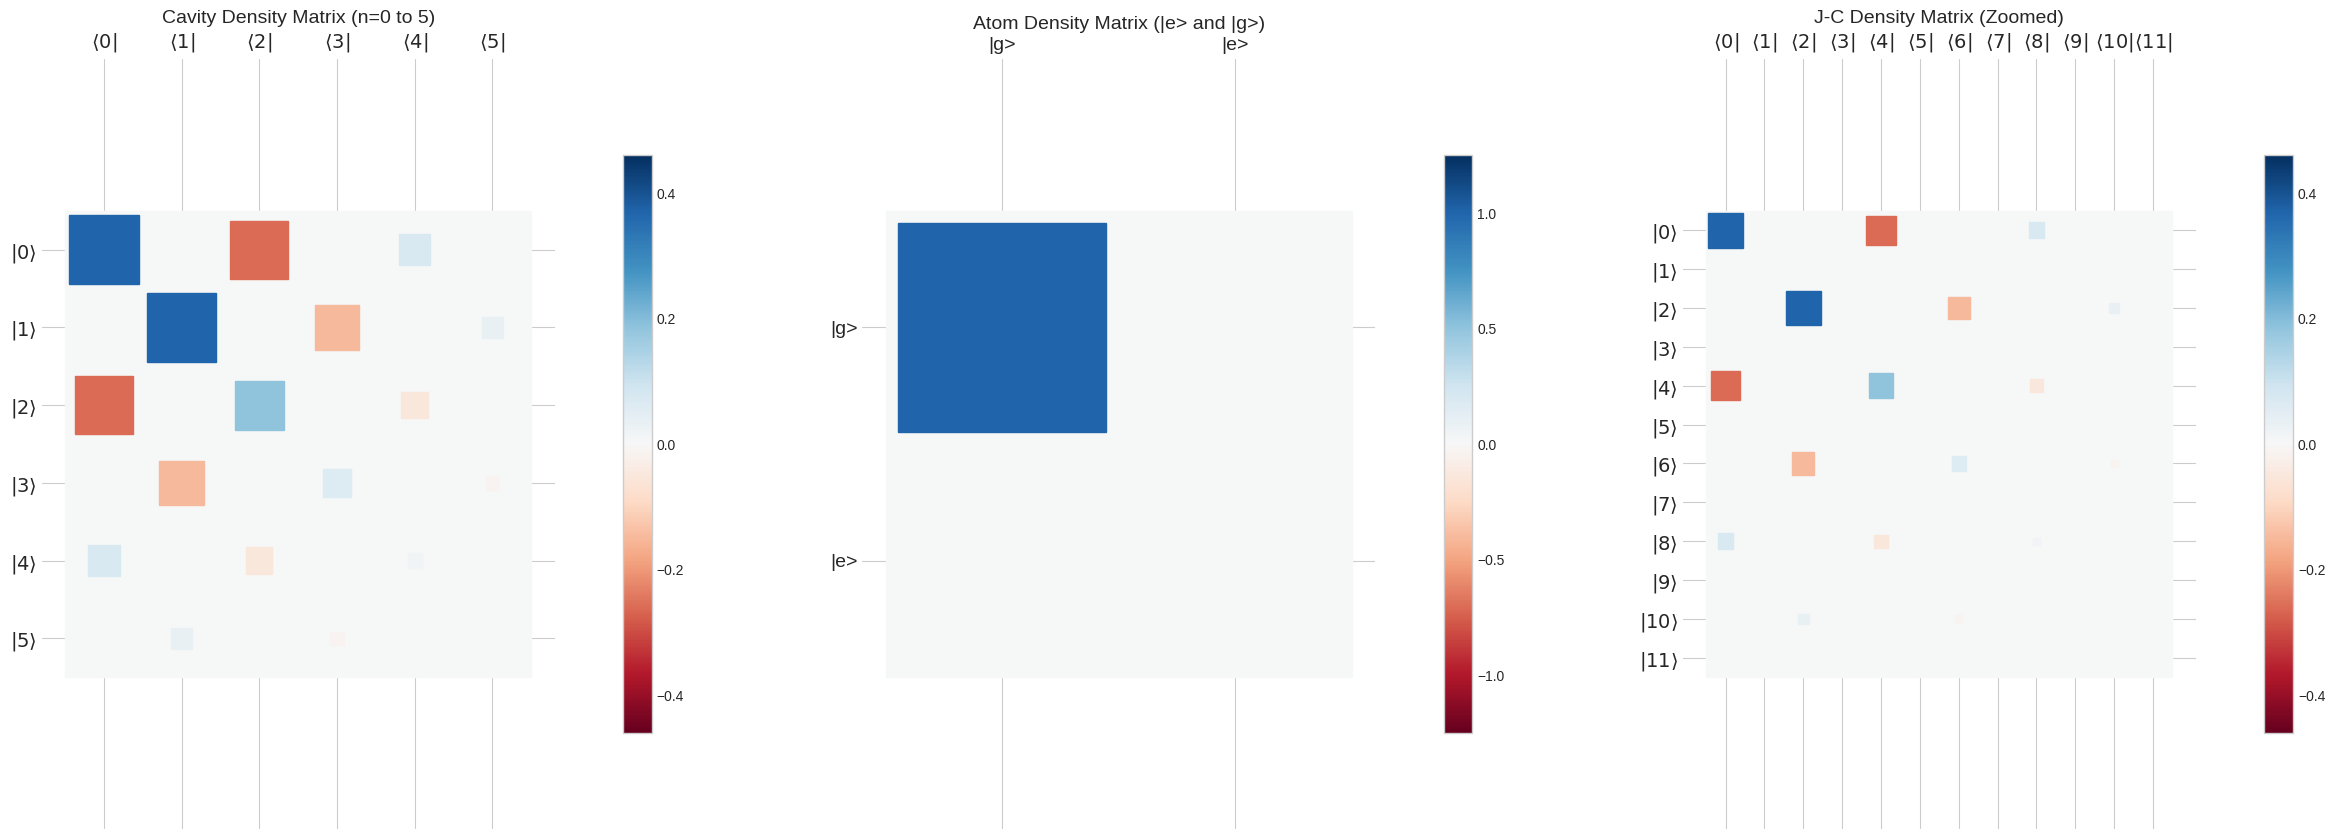

In [284]:
import qutip as qt
import matplotlib.pyplot as plt

# Define how many photon states to display (e.g., the first 6)
n_display = int(N/3) 
rho_ss = qt.steadystate(Ht_0, c_op_list)

# 1. Cavity Density Matrix (Zoomed)
# Convert to a full numpy array, slice it, and wrap it back in a Qobj
rho_cav_sub = qt.Qobj(rho_ss.ptrace(0)[:n_display, :n_display])

# 2. Full J-C Density Matrix (Zoomed)
# Since this is a composite system (N_cav * 2), 
# we slice the first (n_display * 2) rows and columns
rho_total_sub = qt.Qobj(rho_ss[:n_display*2, :n_display*2])

# Now the rest of your plotting code will work:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))


qt.hinton(rho_cav_sub, ax=ax[0])
ax[0].set_title(f"Cavity Density Matrix (n=0 to {n_display-1})", fontsize=14)

# 2. Atom Density Matrix
# No need to crop here as it is always 2x2
qt.hinton(rho_ss.ptrace(1), ax=ax[1])
ax[1].set_title("Atom Density Matrix (|e> and |g>)", fontsize=14)
ax[1].set_xticklabels(['|g>', '|e>'])
ax[1].set_yticklabels(['|e>', '|g>'])

# 3. Full J-C Density Matrix (Zoomed)
# The full space is (N_cav * 2). We slice to see (n_display * 2)


qt.hinton(rho_total_sub, ax=ax[2])
ax[2].set_title("J-C Density Matrix (Zoomed)", fontsize=14)

#plt.tight_layout()
plt.show()

In [285]:
if not_coupling:
    g = 0
    da = 0
    dc = 0

# Hamiltonian
Ht_0 =  E*(a.dag() + a)

# Find steady state directly to avoid tlist issues
rho_ss = qt.steadystate(Ht_0, c_op_list)

# Check the expected <n>
n_expected = (4 * E**2) / (kappa**2)
print(f"Theoretical <n>: {n_expected}")
print(f"Simulated <n>: {qt.expect(a.dag()*a, rho_ss)}")

Theoretical <n>: 1.0
Simulated <n>: 0.9999999999999981


Text(0.5, 1.0, 'Final Cavity Occupation Histogram')

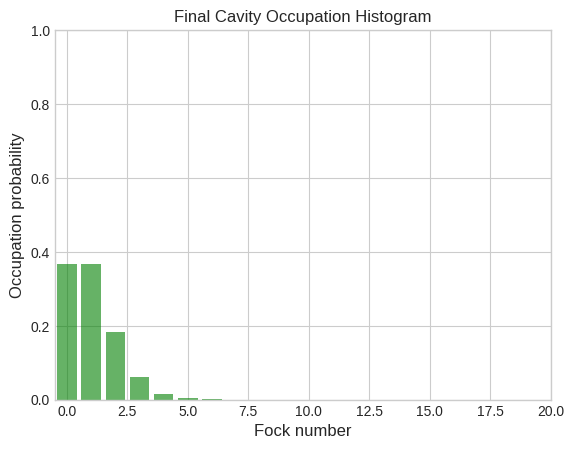

In [286]:
from qutip.visualization import plot_fock_distribution

# 1. Get the final state from your 'output'
final_state = output.states[-1]

# 2. Trace out the atom (index 1) to get the cavity density matrix (index 0)
rho_cavity = final_state.ptrace(0)

# 3. Plot the distribution
fig, ax = plot_fock_distribution(rho_cavity)
ax.set_title("Final Cavity Occupation Histogram")

Text(0.5, 1.0, 'Final Atom Occupation Histogram')

/usr/share/positron/resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/IPython/core/events.py:82: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  func(*args, **kwargs)
/usr/share/positron/resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/IPython/core/pylabtools.py:152: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


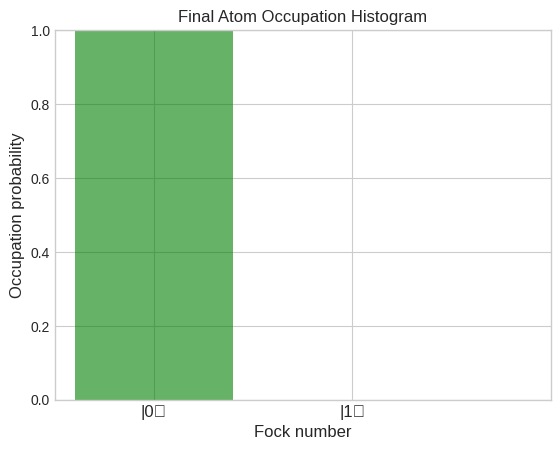

In [287]:
from qutip.visualization import plot_fock_distribution

# 1. Get the final state from your 'output'
final_state = output.states[-1]

# 2. Trace out the atom (index 1) to get the cavity density matrix (index 0)
rho_atom = final_state.ptrace(1)

# 3. Plot the distribution
fig, ax = plot_fock_distribution(rho_atom,fock_numbers=['|0⟩','|1⟩'])
ax.set_title("Final Atom Occupation Histogram")

## 3. Integrate the master equation for enough large times to find the steady state. What is the mean photon number $\langle \hat{a}^\dagger \hat{a} \rangle$? What is the steady-state occupation of the $n$-photon states? Plot the histogram of occupations and compare with a coherent state distribution. [Suggestion: work in a regime of parameters that allow you to keep the photon Hilbert space sufficiently small (e.g. max $10 - 50$ photon states) and the average photon number of the steady state small, $\langle \hat{a}^\dagger \hat{a} \rangle \le 10$. Explain how you made your choice.]



In [288]:
n_avg = qt.expect(a.dag() * a, final_state)
print("Mean photon number of the n-th photon (RWA): ", n_avg)

rho_ss = qt.steadystate(Ht_0, c_op_list)
n_avg = qt.expect(a.dag() * a, rho_ss)
print("Mean photon number in steady state (RWA): ", n_avg)
rho_coherent = qt.tensor(qt.coherent_dm(N=N, alpha=np.sqrt(1)),qt.coherent_dm(N=2, alpha=np.sqrt(1)))
n_avg = qt.expect(a.dag() * a, rho_coherent)
print("Mean photon number in a coherent state : ", n_avg)



Mean photon number of the n-th photon (RWA):  0.9999092022053248
Mean photon number in steady state (RWA):  0.9999999999999981
Mean photon number in a coherent state :  1.0000000000000002


Mean photon number: 1.0000


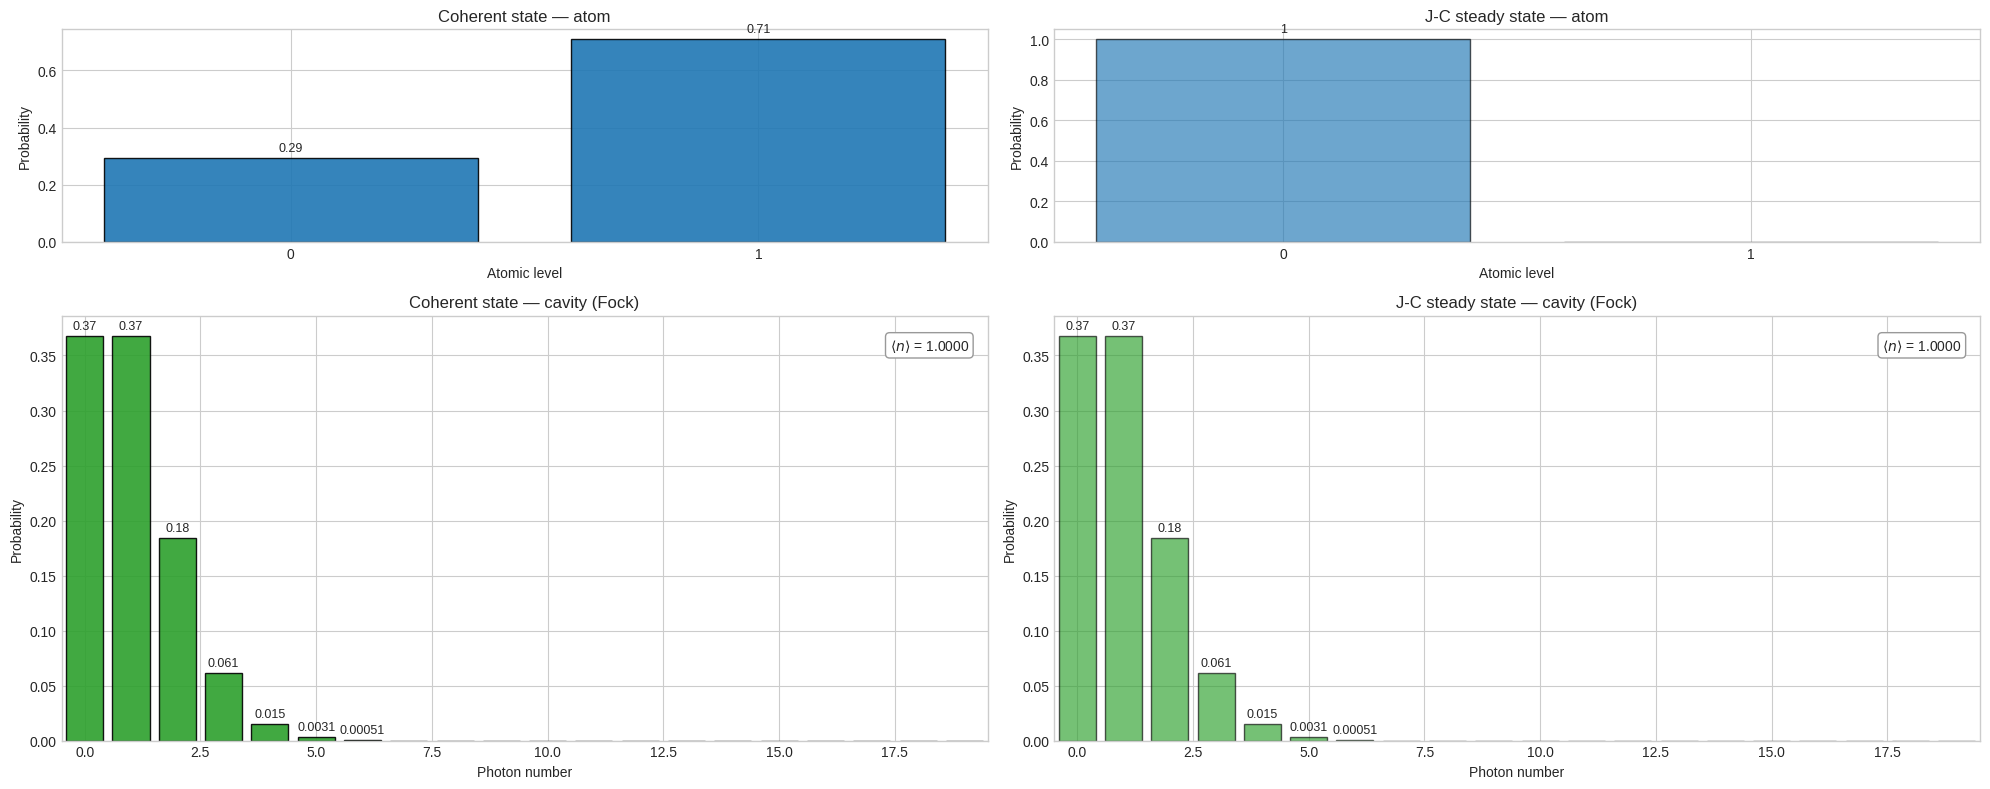

In [289]:
# python
import numpy as np
import matplotlib.pyplot as plt

def improved_fock_plot(cn_atom, cn_cavity, pn_atom, pn_cavity, N, n_avg=None, n_avg_cho=None, figsize=(20,8)):
    """
    Improved 2x2 bar plots for coherent vs steady-state Fock distributions.
    Returns: matplotlib.figure.Figure
    """
    plt.style.use("seaborn-v0_8-whitegrid")
    cmap = plt.get_cmap("tab10")
    atom_color = cmap(0)
    cavity_color = cmap(2)

    # prepare x ranges
    x_atom = np.arange(len(cn_atom))
    x_cavity = np.arange(len(cn_cavity))
    x_cavity_plot_max = min(N, len(cn_cavity))

    fig, axes = plt.subplots(2, 2, figsize=figsize, gridspec_kw={"height_ratios": (1, 2)})
    ax00, ax01 = axes[0,0], axes[0,1]
    ax10, ax11 = axes[1,0], axes[1,1]

    # Coherent state (atom, cavity)
    ax00.bar(x_atom, cn_atom, color=atom_color, edgecolor="k", alpha=0.9)
    ax00.set_title("Coherent state — atom")
    ax00.set_xlabel("Atomic level")
    ax00.set_ylabel("Probability")
    ax00.set_xticks(x_atom)

    ax10.bar(x_cavity[:x_cavity_plot_max], cn_cavity[:x_cavity_plot_max],
             color=cavity_color, edgecolor="k", alpha=0.9, width=0.8)
    ax10.set_title("Coherent state — cavity (Fock)")
    ax10.set_xlabel("Photon number")
    ax10.set_ylabel("Probability")
    ax10.set_xlim(-0.5, x_cavity_plot_max - 0.5)

    # J-C steady state (atom, cavity)
    ax01.bar(x_atom, pn_atom, color=atom_color, edgecolor="k", alpha=0.65)
    ax01.set_title("J-C steady state — atom")
    ax01.set_xlabel("Atomic level")
    ax01.set_ylabel("Probability")
    ax01.set_xticks(x_atom)

    ax11.bar(x_cavity[:x_cavity_plot_max], pn_cavity[:x_cavity_plot_max],
             color=cavity_color, edgecolor="k", alpha=0.65, width=0.8)
    ax11.set_title("J-C steady state — cavity (Fock)")
    ax11.set_xlabel("Photon number")
    ax11.set_ylabel("Probability")
    ax11.set_xlim(-0.5, x_cavity_plot_max - 0.5)

    # small annotations: annotate bars above threshold
    def annotate_bars(ax, bars, fmt="{:.2g}", thresh=1e-3, va="bottom", fontsize=9):
        for bar in bars:
            h = bar.get_height()
            if h > thresh:
                ax.annotate(fmt.format(h),
                            xy=(bar.get_x() + bar.get_width()/2, h),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va=va, fontsize=fontsize)

    annotate_bars(ax00, ax00.patches)
    annotate_bars(ax01, ax01.patches)
    annotate_bars(ax10, ax10.patches, thresh=1e-4)
    annotate_bars(ax11, ax11.patches, thresh=1e-4)

    # visually emphasize low-probability tail: enable minor ticks and log y-scale alternative
    for ax in (ax10, ax11):
        #ax.yaxis.set_minor_locator(plt.AutoMinorLocator())
        ax.grid(which="minor", alpha=0.15)

    # add a small textbox with mean photon number (if provided)
    if n_avg is not None:
        txt = rf"$\langle n \rangle$ = {n_avg:.4f}"
        ax11.text(0.98, 0.95, txt, transform=ax11.transAxes,
                  ha="right", va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))
    if n_avg_cho is not None:    
        txt = rf"$\langle n \rangle$ = {n_avg_cho:.4f}"
        ax10.text(0.98, 0.95, txt, transform=ax10.transAxes,
                  ha="right", va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

    fig.tight_layout()
    return fig

# Usage: (uses variables already in your session)
n_avg = qt.expect(a.dag() * a, rho_ss)
n_avg_cho = qt.expect(a.dag() * a, rho_coherent)
pn_cavity = rho_ss.ptrace(0).diag().real  # Photon number distribution
pn_atom = rho_ss.ptrace(1).diag().real  # Atomic levels number distribution
cn_cavity = rho_coherent.ptrace(0).diag().real
cn_atom = rho_coherent.ptrace(1).diag().real
print(f"Mean photon number: {n_avg:.4f}")
fig = improved_fock_plot(cn_atom, cn_cavity, pn_atom, pn_cavity, N, n_avg, n_avg_cho)


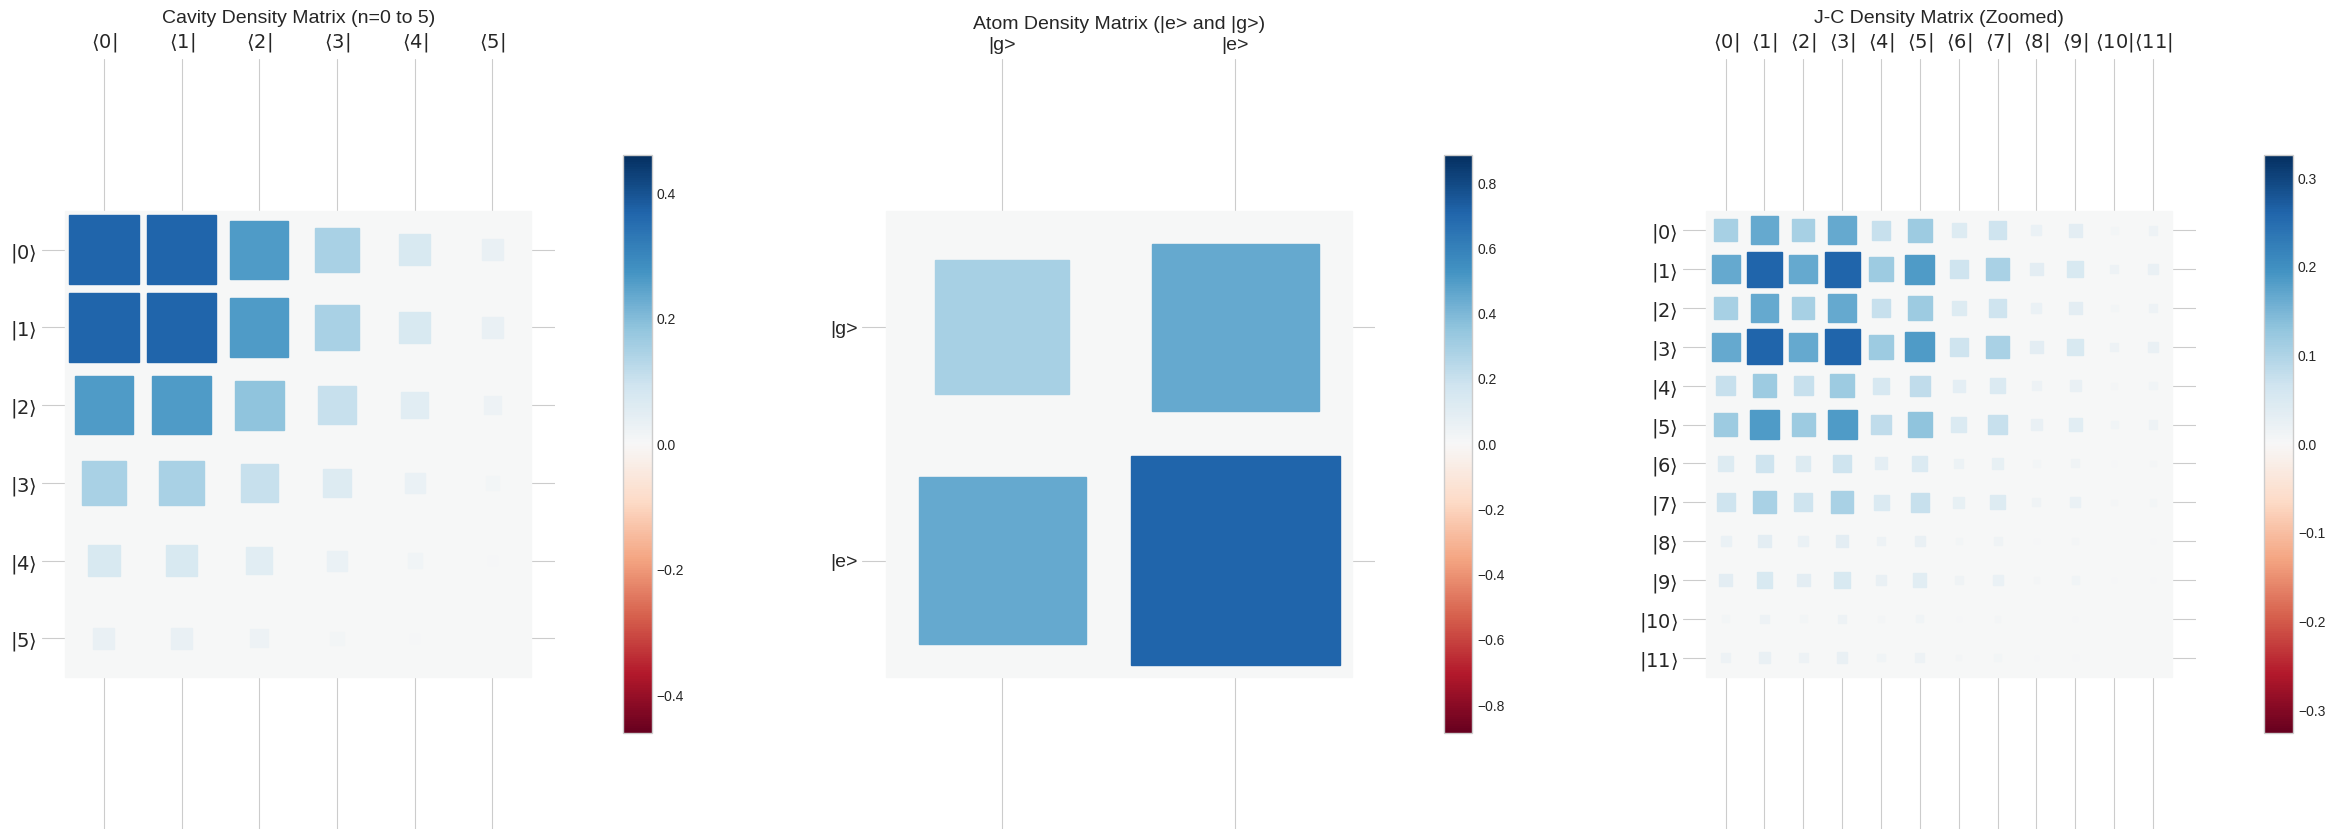

In [290]:
import qutip as qt
import matplotlib.pyplot as plt

# Define how many photon states to display (e.g., the first 6)
n_display = int(N/3) 
#rho_ss = qt.steadystate(Ht_0, c_op_list)

# 1. Cavity Density Matrix (Zoomed)
# Convert to a full numpy array, slice it, and wrap it back in a Qobj
rho_cav_sub = qt.Qobj(rho_coherent.ptrace(0)[:n_display, :n_display])

# 2. Full J-C Density Matrix (Zoomed)
# Since this is a composite system (N_cav * 2), 
# we slice the first (n_display * 2) rows and columns
rho_total_sub = qt.Qobj(rho_coherent[:n_display*2, :n_display*2])

# Now the rest of your plotting code will work:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))


qt.hinton(rho_cav_sub, ax=ax[0])
ax[0].set_title(f"Cavity Density Matrix (n=0 to {n_display-1})", fontsize=14)

# 2. Atom Density Matrix
# No need to crop here as it is always 2x2
qt.hinton(rho_coherent.ptrace(1), ax=ax[1])
ax[1].set_title("Atom Density Matrix (|e> and |g>)", fontsize=14)
ax[1].set_xticklabels(['|g>', '|e>'])
ax[1].set_yticklabels(['|e>', '|g>'])

# 3. Full J-C Density Matrix (Zoomed)
# The full space is (N_cav * 2). We slice to see (n_display * 2)


qt.hinton(rho_total_sub, ax=ax[2])
ax[2].set_title("J-C Density Matrix (Zoomed)", fontsize=14)

#plt.tight_layout()
plt.show()

## 4. In the presence of a coupling $\tilde{g}$, the previous resonance condition is not valid anymore. Set $\omega$ to resonance with the lowest (one-photon) dressed state of the Jaynes-Cummings model and find again the steady state in the strong-coupling condition $\tilde{g} \gg \Gamma, \kappa$ and weak drive $\mathcal{E}$. How important is the value of the pumping strength $\mathcal{E}$? (Be careful that increasing $\mathcal{E}$ too much could lead to instability/bistability)

/home/phuniverse/Desktop/master/QIAP/code/.venv/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/home/phuniverse/Desktop/master/QIAP/code/.venv/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


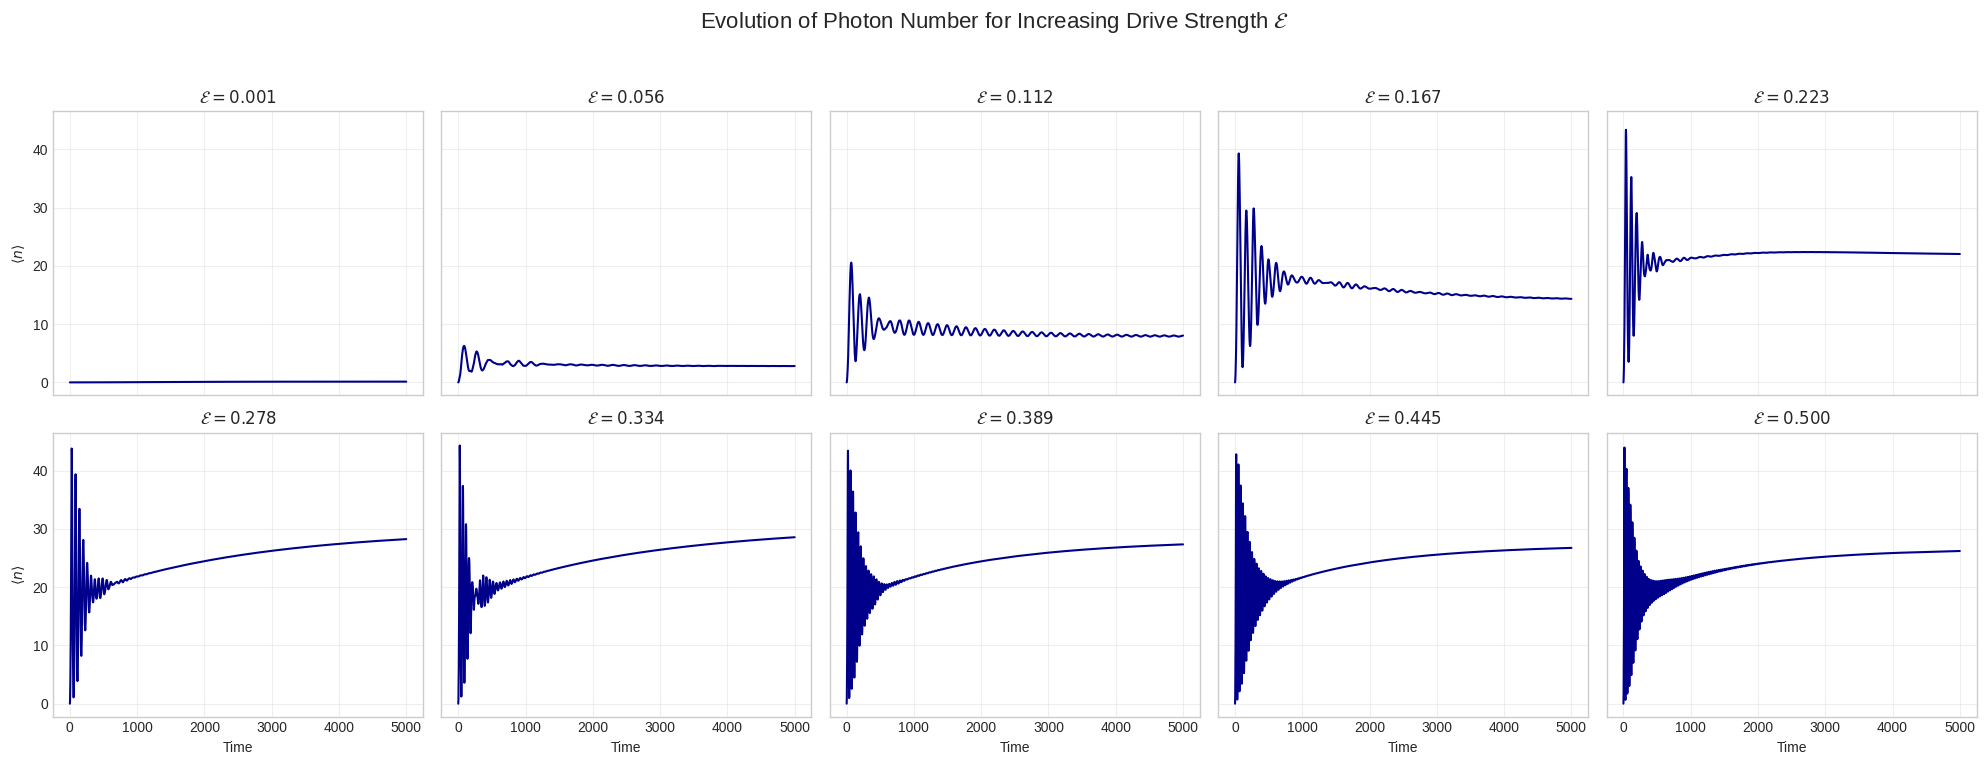

In [291]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# --- Your original parameters ---
N = 50
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
#E = 0.0005 # Reduced slightly to ensure deep antibunching
w_drive = wc - g 

a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 0)) 
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]
tlist = np.linspace(0, 5000 , 2000)

# Range of drive strengths
E_values = np.linspace(0.0005, 0.5, 10) # Adjusted max E to keep N=25 valid

# --- Plotting the Grid ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
dc = wc - w_drive
da = wa - w_drive
for i, E in enumerate(E_values):
    # Hamiltonian for this specific E
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Solve
    output = qt.mesolve(H, psi0, tlist, c_ops, [a.dag() * a])
    
    # Plot in the grid
    axes[i].plot(tlist, output.expect[0], label=f'E={E:.3f}', color='darkblue')
    axes[i].set_title(rf"$\mathcal{{E}} = {E:.3f}$")
    axes[i].grid(alpha=0.3)
    
    if i >= 5:
        axes[i].set_xlabel("Time")
    if i % 5 == 0:
        axes[i].set_ylabel(r"$\langle n \rangle$")

plt.suptitle(r"Evolution of Photon Number for Increasing Drive Strength $\mathcal{E}$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<positron-console-cell-292>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<positron-console-cell-292>:50: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.


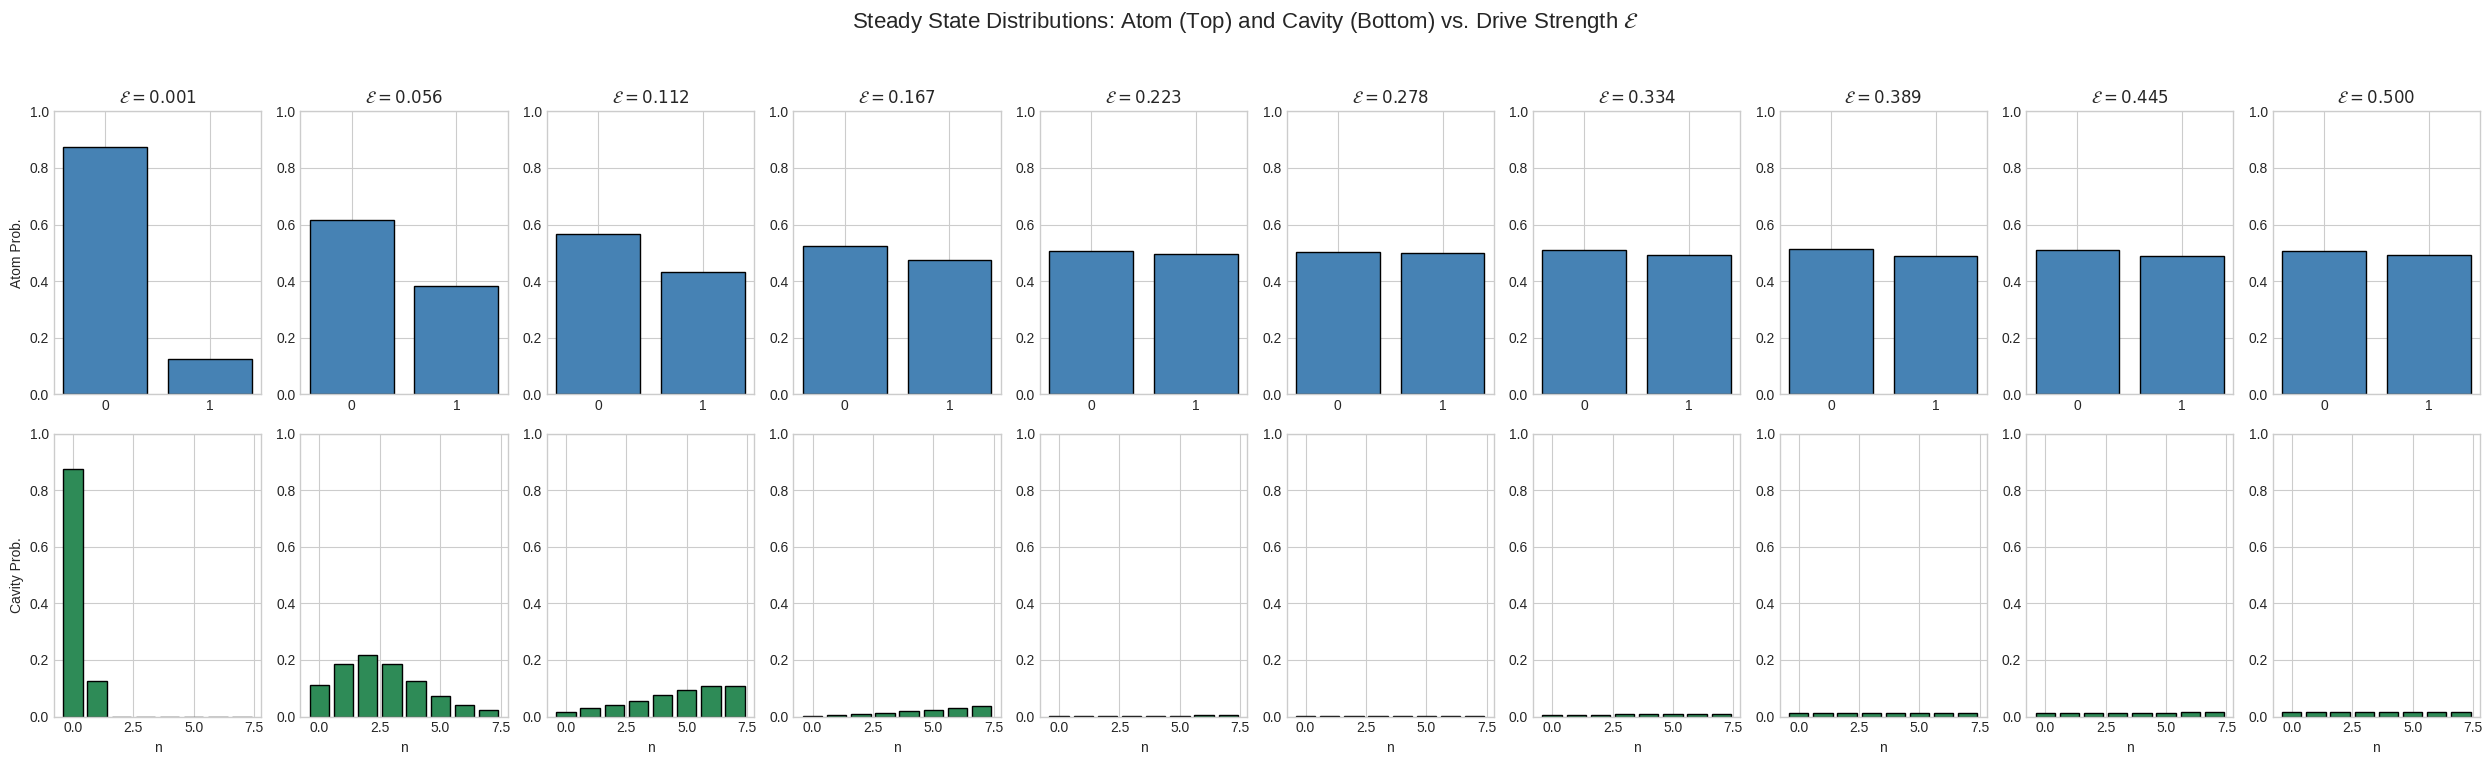

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters from your setup
N = 50
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
w_drive = wc - g # Resonant with the first dressed state

# Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# Using your E_values
E_values = np.linspace(0.0005, 0.5, 10) 

# Setup Grid: 2 rows (Atom, Cavity) x 10 columns (E values)
fig, axes = plt.subplots(2, 10, figsize=(25, 8))
dc = wc - w_drive
da = wa - w_drive
for i, E in enumerate(E_values):
    # Hamiltonian in rotating frame at w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Calculate steady state
    rho_ss = qt.steadystate(H, c_ops)
    
    # 1. Atomic Distribution (Top Row)
    atom_dist = qt.ptrace(rho_ss, 1).diag().real
    axes[0, i].bar([0, 1], atom_dist, color='steelblue', edgecolor='black')
    axes[0, i].set_title(f"$\mathcal{{E}} = {E:.3f}$")
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_xticks([0, 1])
    if i == 0: axes[0, i].set_ylabel("Atom Prob.")

    # 2. Cavity Fock Distribution (Bottom Row)
    cavity_dist = qt.ptrace(rho_ss, 0).diag().real
    axes[1, i].bar(range(8), cavity_dist[:8], color='seagreen', edgecolor='black')
    axes[1, i].set_ylim(0, 1)
    if i == 0: axes[1, i].set_ylabel("Cavity Prob.")
    axes[1, i].set_xlabel("n")

plt.suptitle("Steady State Distributions: Atom (Top) and Cavity (Bottom) vs. Drive Strength $\mathcal{E}$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5. Can you have occupation of two photon states? If not, why? What happens if you increase the values of the decay rates? And if you change $\tilde{g}$?

In [314]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
# 1. New Resonance Condition (Lowest Dressed State)
# Energy level is E_1- = hbar * (wc - g)
w_drive = wc - g 

# 2. Operators & Hamiltonian setup
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 0)) # Start in ground state
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# 3. Time evolution settings
tlist = np.linspace(0, 5000 , 2000)# Long enough to reach steady state

# Range of drive strengths to test
g_values = np.linspace(g/100, g,10) 
results_g = {}
results_gg2 = {}

dc = wc -w_drive
da = wa-w_drive
for g in g_values:
    # Hamiltonian in the frame rotating at w_drive
    current_w_drive = wc - g 
    dc = wc - current_w_drive # This will now equal g
    da = wa - current_w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Solve time evolution
    output = qt.mesolve(H, psi0, tlist, c_ops, [a.dag() * a,a.dag() * a.dag() * a * a])
    #results_g[g] = output.expect[1]/(output.expect[0]**2)
    results_gg2[g] = output.expect[1]



/home/phuniverse/Desktop/master/QIAP/code/.venv/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


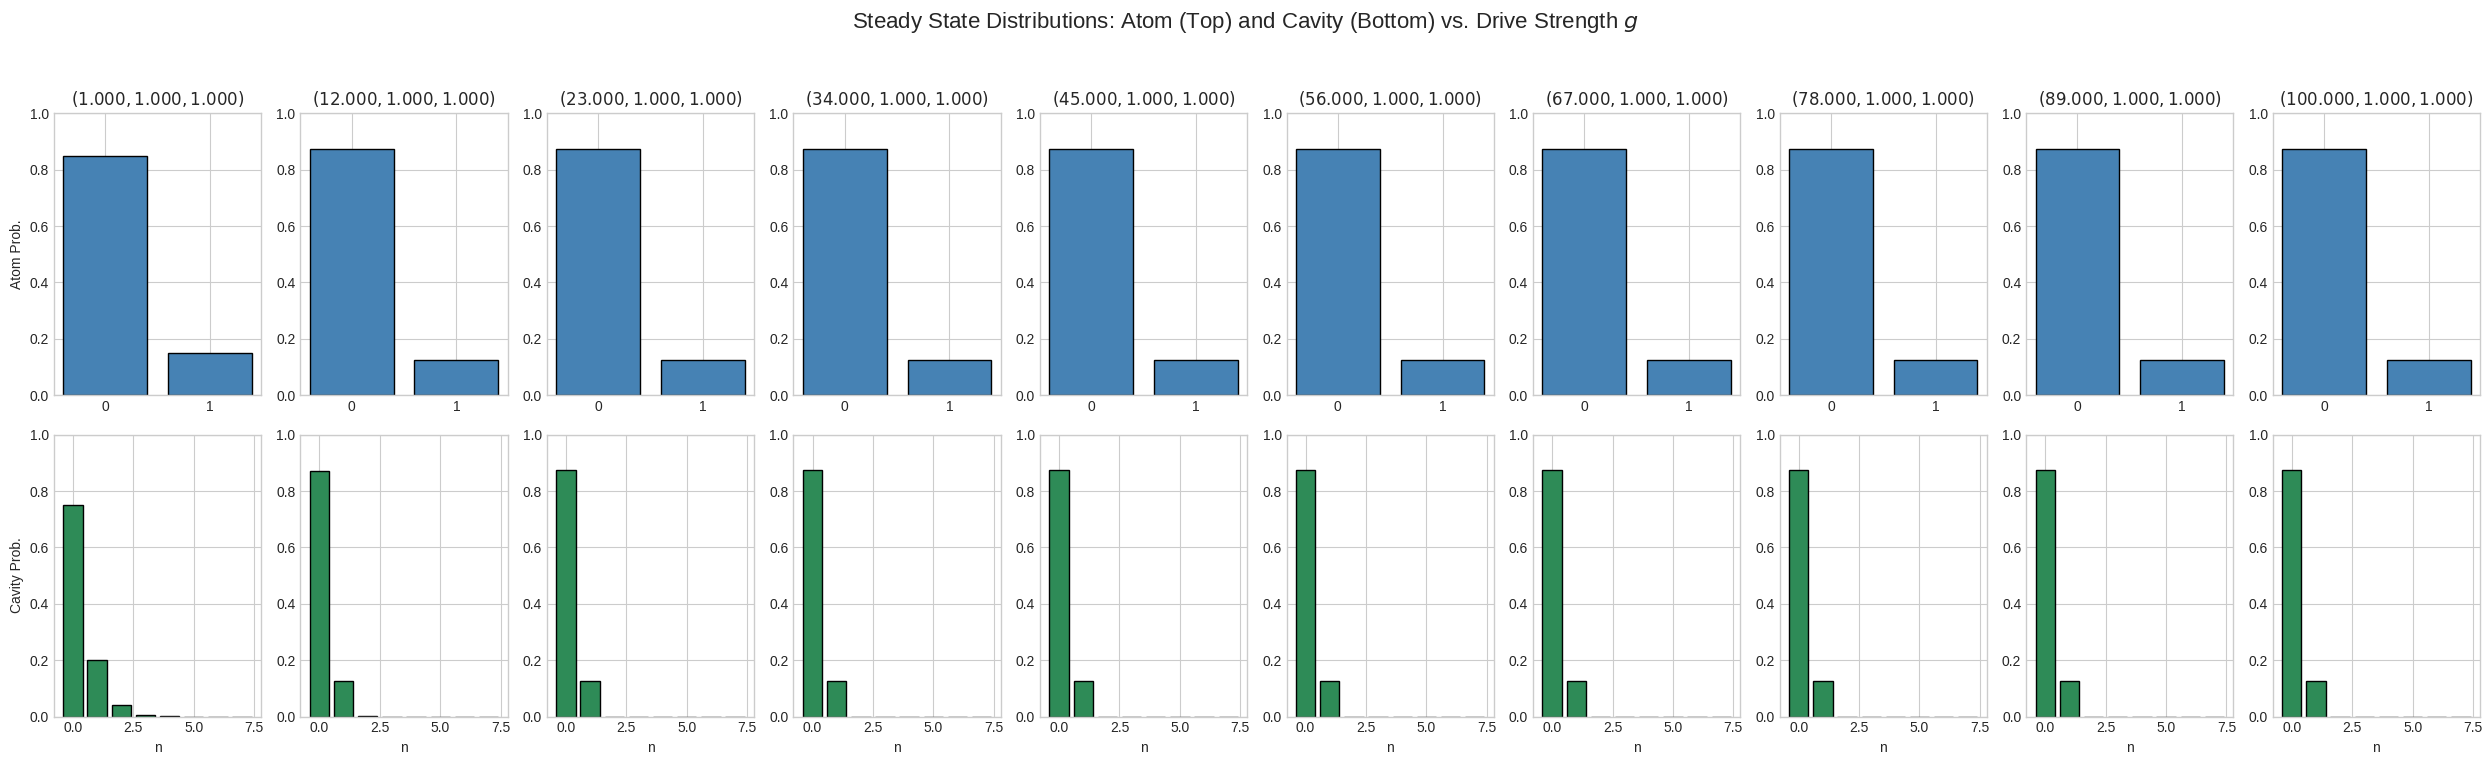

In [315]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters from your setup
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
w_drive = wc - g # Resonant with the first dressed state

# Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]



# Setup Grid: 2 rows (Atom, Cavity) x 10 columns (E values)
fig, axes = plt.subplots(2, 10, figsize=(25, 8))
dc = wc - w_drive
da = wa - w_drive
for i, g in enumerate(g_values):
    # Hamiltonian in rotating frame at w_drive
    current_w_drive = wc - g 
    dc = wc - current_w_drive # This will now equal g
    da = wa - current_w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Calculate steady state
    rho_ss = qt.steadystate(H, c_ops)
    
    # 1. Atomic Distribution (Top Row)
    atom_dist = qt.ptrace(rho_ss, 1).diag().real
    axes[0, i].bar([0, 1], atom_dist, color='steelblue', edgecolor='black')
    axes[0, i].set_title(rf"$({g/kappa:.3f},{kappa/kappa:.3f},{gamma/kappa:.3f})$")
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_xticks([0, 1])
    if i == 0: axes[0, i].set_ylabel("Atom Prob.")

    # 2. Cavity Fock Distribution (Bottom Row)
    cavity_dist = qt.ptrace(rho_ss, 0).diag().real
    axes[1, i].bar(range(8), cavity_dist[:8], color='seagreen', edgecolor='black')
    axes[1, i].set_ylim(0, 1)
    if i == 0: axes[1, i].set_ylabel("Cavity Prob.")
    axes[1, i].set_xlabel("n")

plt.suptitle(r"Steady State Distributions: Atom (Top) and Cavity (Bottom) vs. Drive Strength $g$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

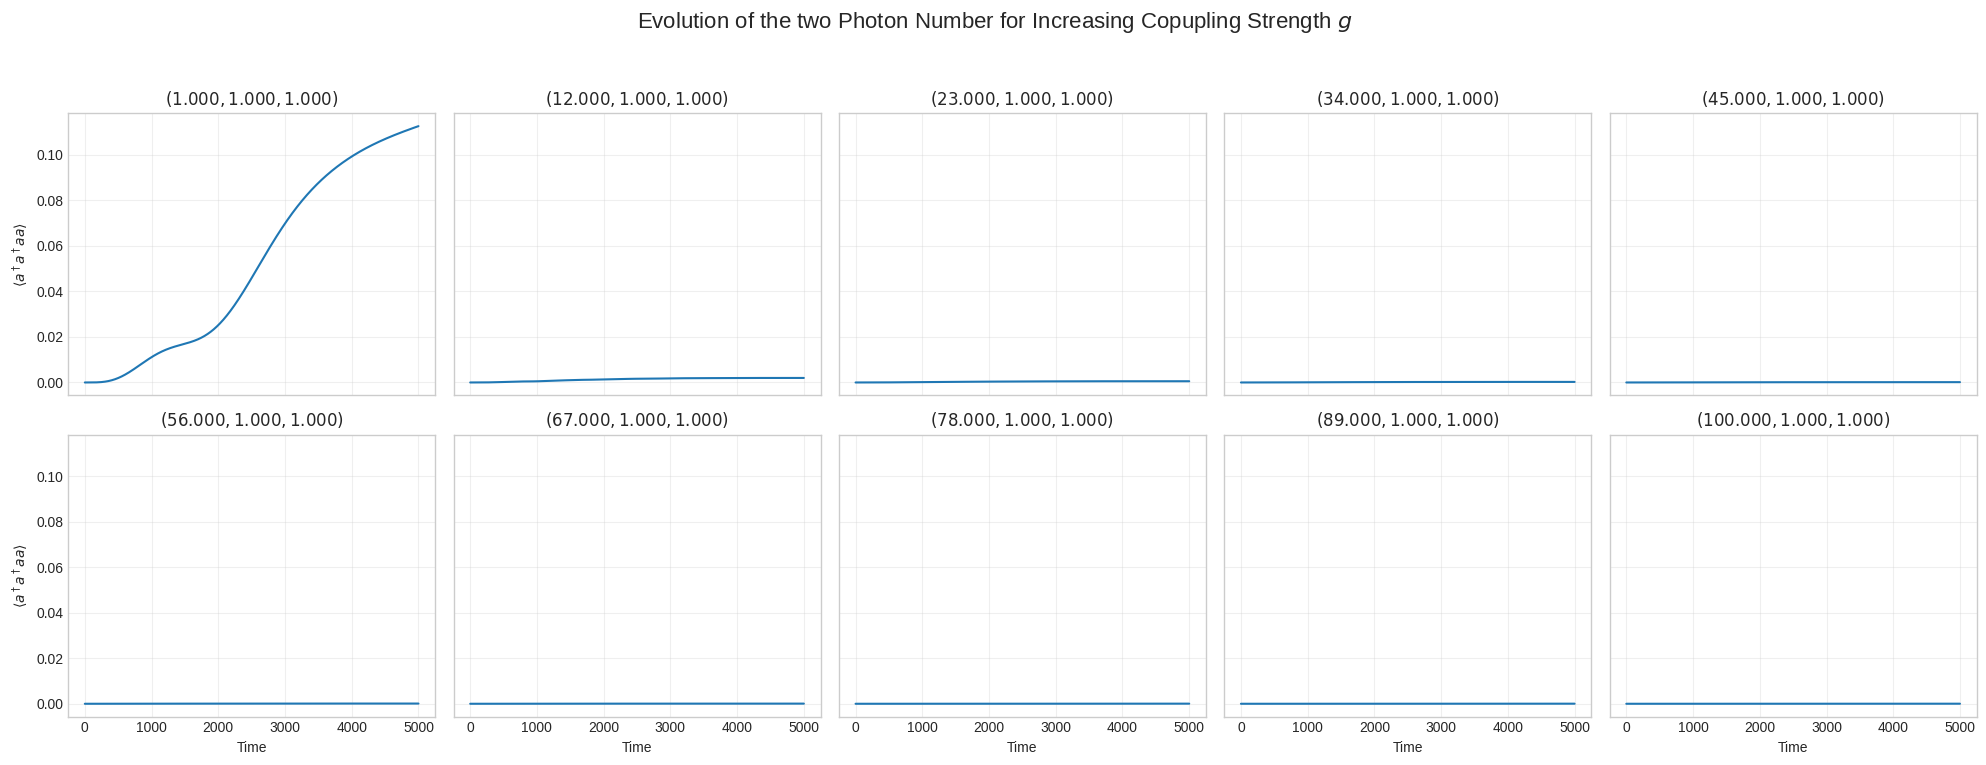

In [316]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i,g in enumerate(g_values):
    axes[i].plot(tlist, results_gg2[g], label=f'g = {g:.2f}')
    axes[i].set_title(rf"$({g/kappa:.3f},{kappa/kappa:.3f},{gamma/kappa:.3f})$")
    axes[i].grid(alpha=0.3)
    
    if i >= 5:
        axes[i].set_xlabel("Time")
    if i % 5 == 0:
        axes[i].set_ylabel(r"$\langle a^\dagger a^\dagger a a\rangle$")

plt.suptitle(r"Evolution of the two Photon Number for Increasing Copupling Strength $g$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
# 1. New Resonance Condition (Lowest Dressed State)
# Energy level is E_1- = hbar * (wc - g)
w_drive = wc - g 

# 2. Operators & Hamiltonian setup
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 0)) # Start in ground state
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# 3. Time evolution settings
tlist = np.linspace(0, 5000 , 2000)# Long enough to reach steady state

# Range of drive strengths to test
k_values = np.linspace(kappa, 100*kappa,10) 
results_k = {}
results_kg2 = {}

dc = wc-w_drive
da = wa -w_drive
for k in k_values:
    # Hamiltonian in the frame rotating at w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Solve time evolution
    c_ops = [np.sqrt(k) * a, np.sqrt(gamma) * sm]
    output = qt.mesolve(H, psi0, tlist, c_ops, [a.dag() * a,a.dag() * a.dag() * a * a])
    #results_k[k] = output.expect[1]/(output.expect[0]**2)
    results_kg2[k] = output.expect[1]



/home/phuniverse/Desktop/master/QIAP/code/.venv/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


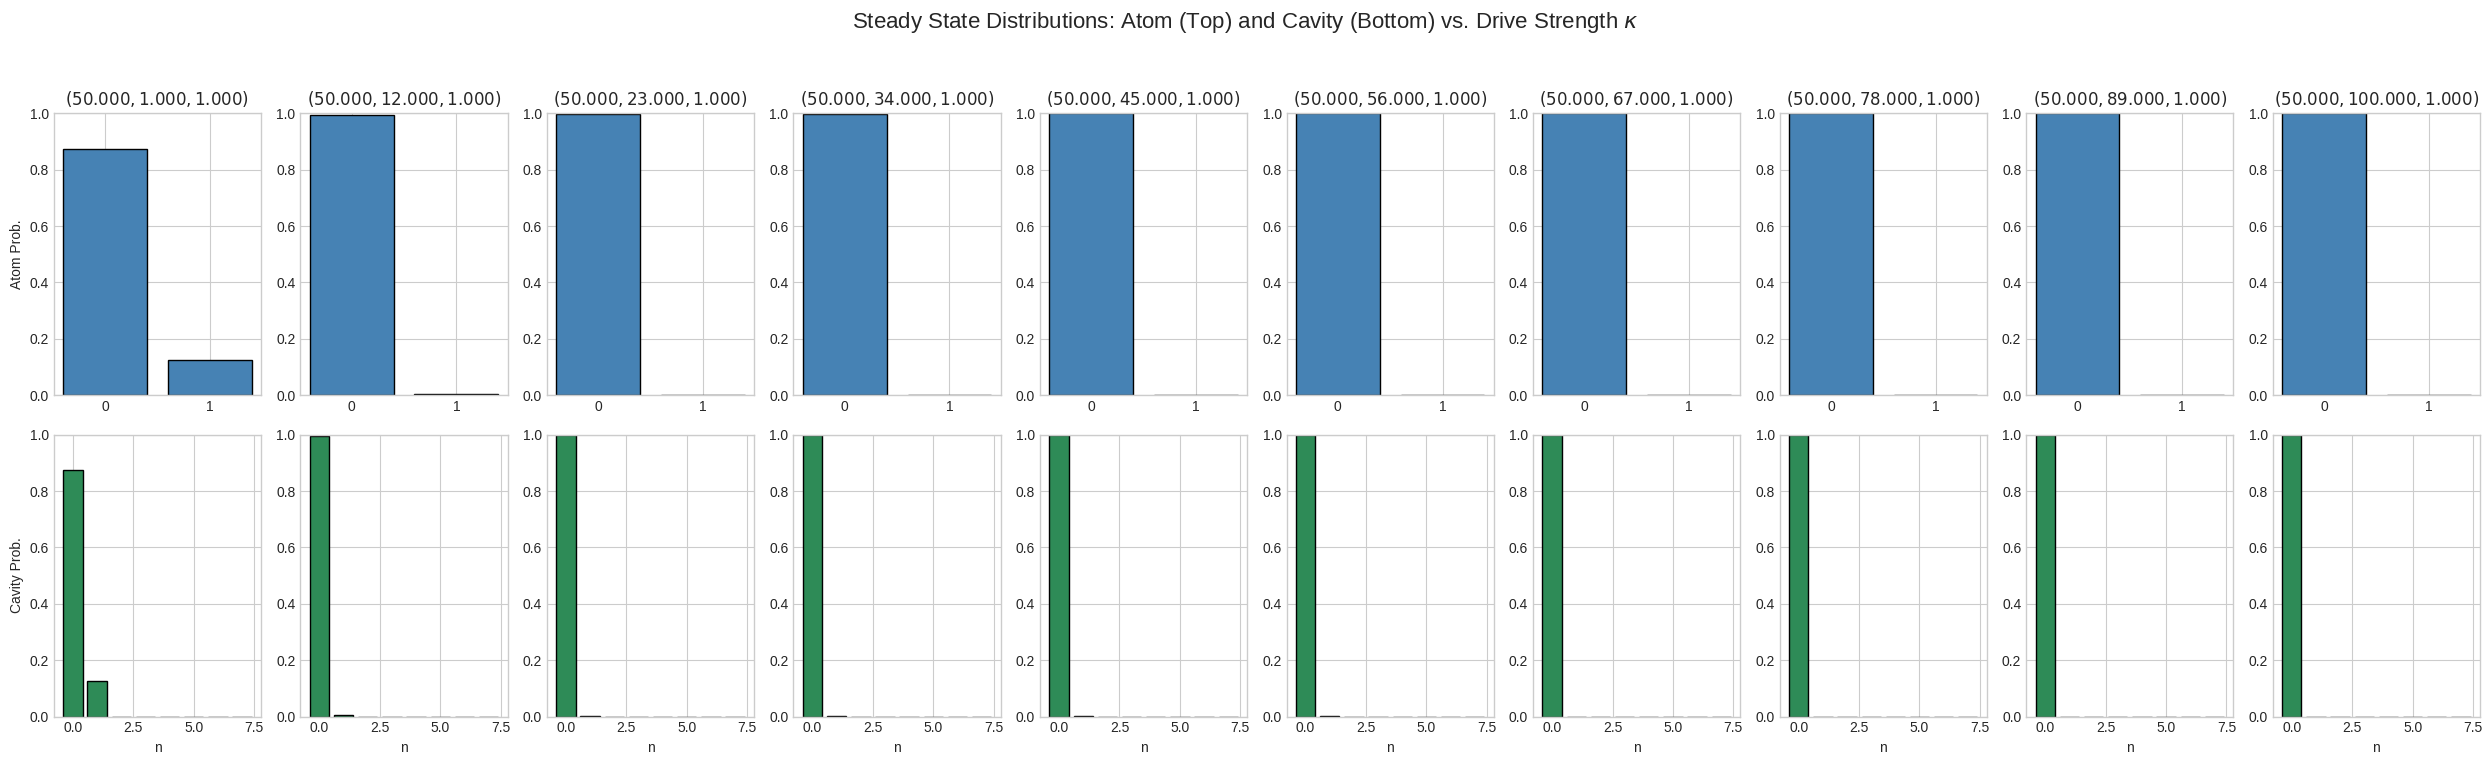

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters from your setup
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
w_drive = wc - g # Resonant with the first dressed state

# Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))




# Setup Grid: 2 rows (Atom, Cavity) x 10 columns (E values)
fig, axes = plt.subplots(2, 10, figsize=(25, 8))
dc = wc - w_drive
da = wa - w_drive
for i, k in enumerate(k_values):
    # Hamiltonian in rotating frame at w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    c_ops = [np.sqrt(k) * a, np.sqrt(gamma) * sm]
    # Calculate steady state
    rho_ss = qt.steadystate(H, c_ops)
    
    # 1. Atomic Distribution (Top Row)
    atom_dist = qt.ptrace(rho_ss, 1).diag().real
    axes[0, i].bar([0, 1], atom_dist, color='steelblue', edgecolor='black')
    axes[0, i].set_title(rf"$({g/kappa:.3f},{k/kappa:.3f},{gamma/kappa:.3f})$")
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_xticks([0, 1])
    if i == 0: axes[0, i].set_ylabel("Atom Prob.")

    # 2. Cavity Fock Distribution (Bottom Row)
    cavity_dist = qt.ptrace(rho_ss, 0).diag().real
    axes[1, i].bar(range(8), cavity_dist[:8], color='seagreen', edgecolor='black')
    axes[1, i].set_ylim(0, 1)
    if i == 0: axes[1, i].set_ylabel("Cavity Prob.")
    axes[1, i].set_xlabel("n")

plt.suptitle(r"Steady State Distributions: Atom (Top) and Cavity (Bottom) vs. Drive Strength $\kappa$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

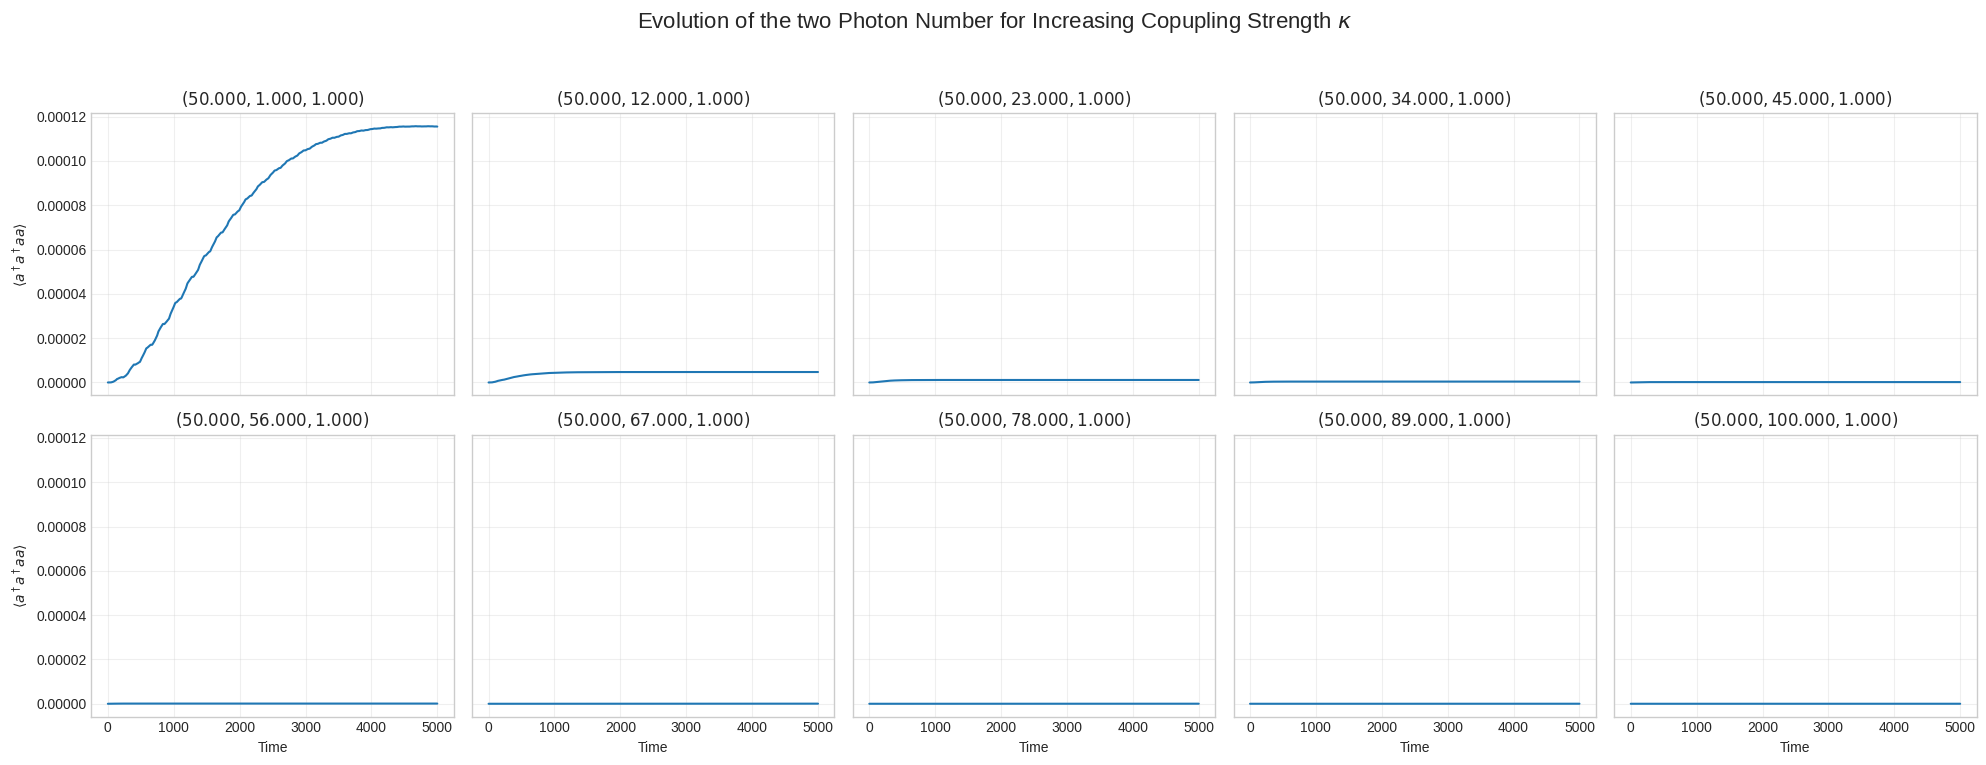

In [298]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i,k in enumerate(k_values):
    axes[i].plot(tlist, results_kg2[k], label=f'g = {g:.2f}')
    axes[i].set_title(rf"$({g/kappa:.3f},{k/kappa:.3f},{gamma/kappa:.3f})$")
    axes[i].grid(alpha=0.3)
    
    if i >= 5:
        axes[i].set_xlabel("Time")
    if i % 5 == 0:
        axes[i].set_ylabel(r"$\langle a^\dagger a^\dagger a a\rangle$")

plt.suptitle(r"Evolution of the two Photon Number for Increasing Copupling Strength $\kappa$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
# 1. New Resonance Condition (Lowest Dressed State)
# Energy level is E_1- = hbar * (wc - g)
w_drive = wc - g 

# 2. Operators & Hamiltonian setup
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
psi0 = qt.tensor(qt.basis(N, 0), qt.basis(2, 0)) # Start in ground state
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# 3. Time evolution settings
tlist = np.linspace(0, 5000 , 2000)# Long enough to reach steady state

# Range of drive strengths to test
ga_values = np.linspace(gamma, 100*gamma,10) 
results_ga = {}
results_gag2 = {}
dc = wc-w_drive
da = wa -w_drive
for ga in ga_values:
    # Hamiltonian in the frame rotating at w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    
    # Solve time evolution
    c_ops = [np.sqrt(kappa) * a, np.sqrt(ga) * sm]
    output = qt.mesolve(H, psi0, tlist, c_ops, [a.dag() * a,a.dag() * a.dag() * a * a])
    #results_ga[ga] = output.expect[1]/(output.expect[0]**2)
    results_gag2[ga] = output.expect[1]


/home/phuniverse/Desktop/master/QIAP/code/.venv/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


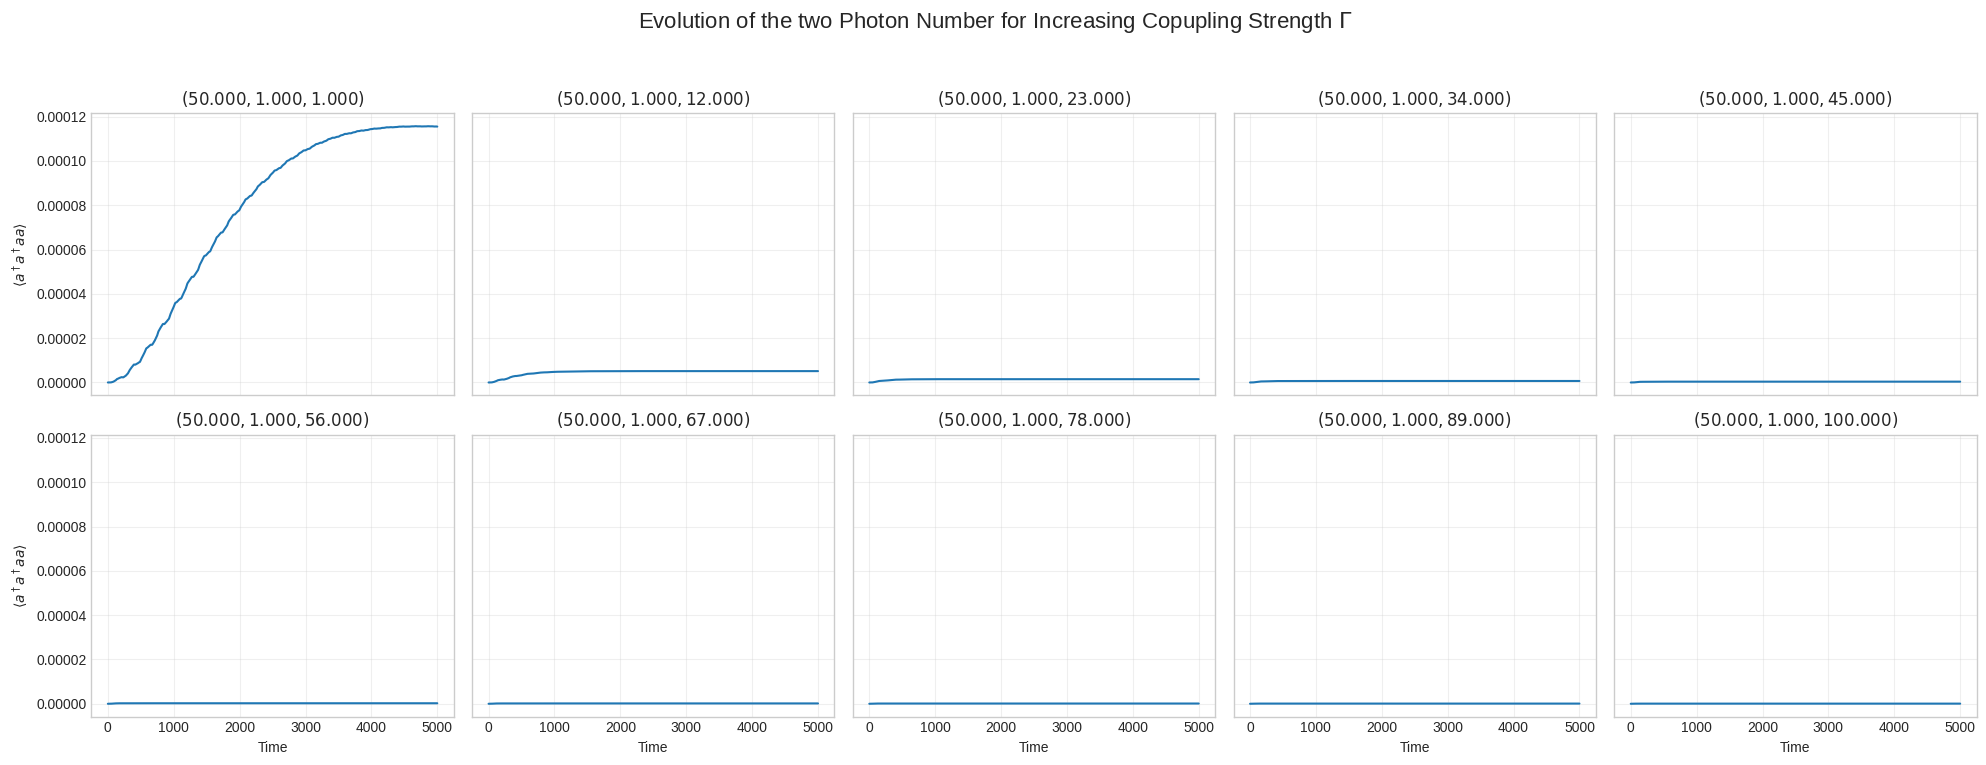

In [300]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i,ga in enumerate(ga_values):
    axes[i].plot(tlist, results_gag2[ga], label=rf'$\Gamma = {ga:.2f}$')
    axes[i].set_title(rf"$({g/kappa:.3f},{kappa/kappa:.3f},{ga/kappa:.3f})$")
    axes[i].grid(alpha=0.3)
    
    if i >= 5:
        axes[i].set_xlabel("Time")
    if i % 5 == 0:
        axes[i].set_ylabel(r"$\langle a^\dagger a^\dagger a a\rangle$")

plt.suptitle(r"Evolution of the two Photon Number for Increasing Copupling Strength $\Gamma$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

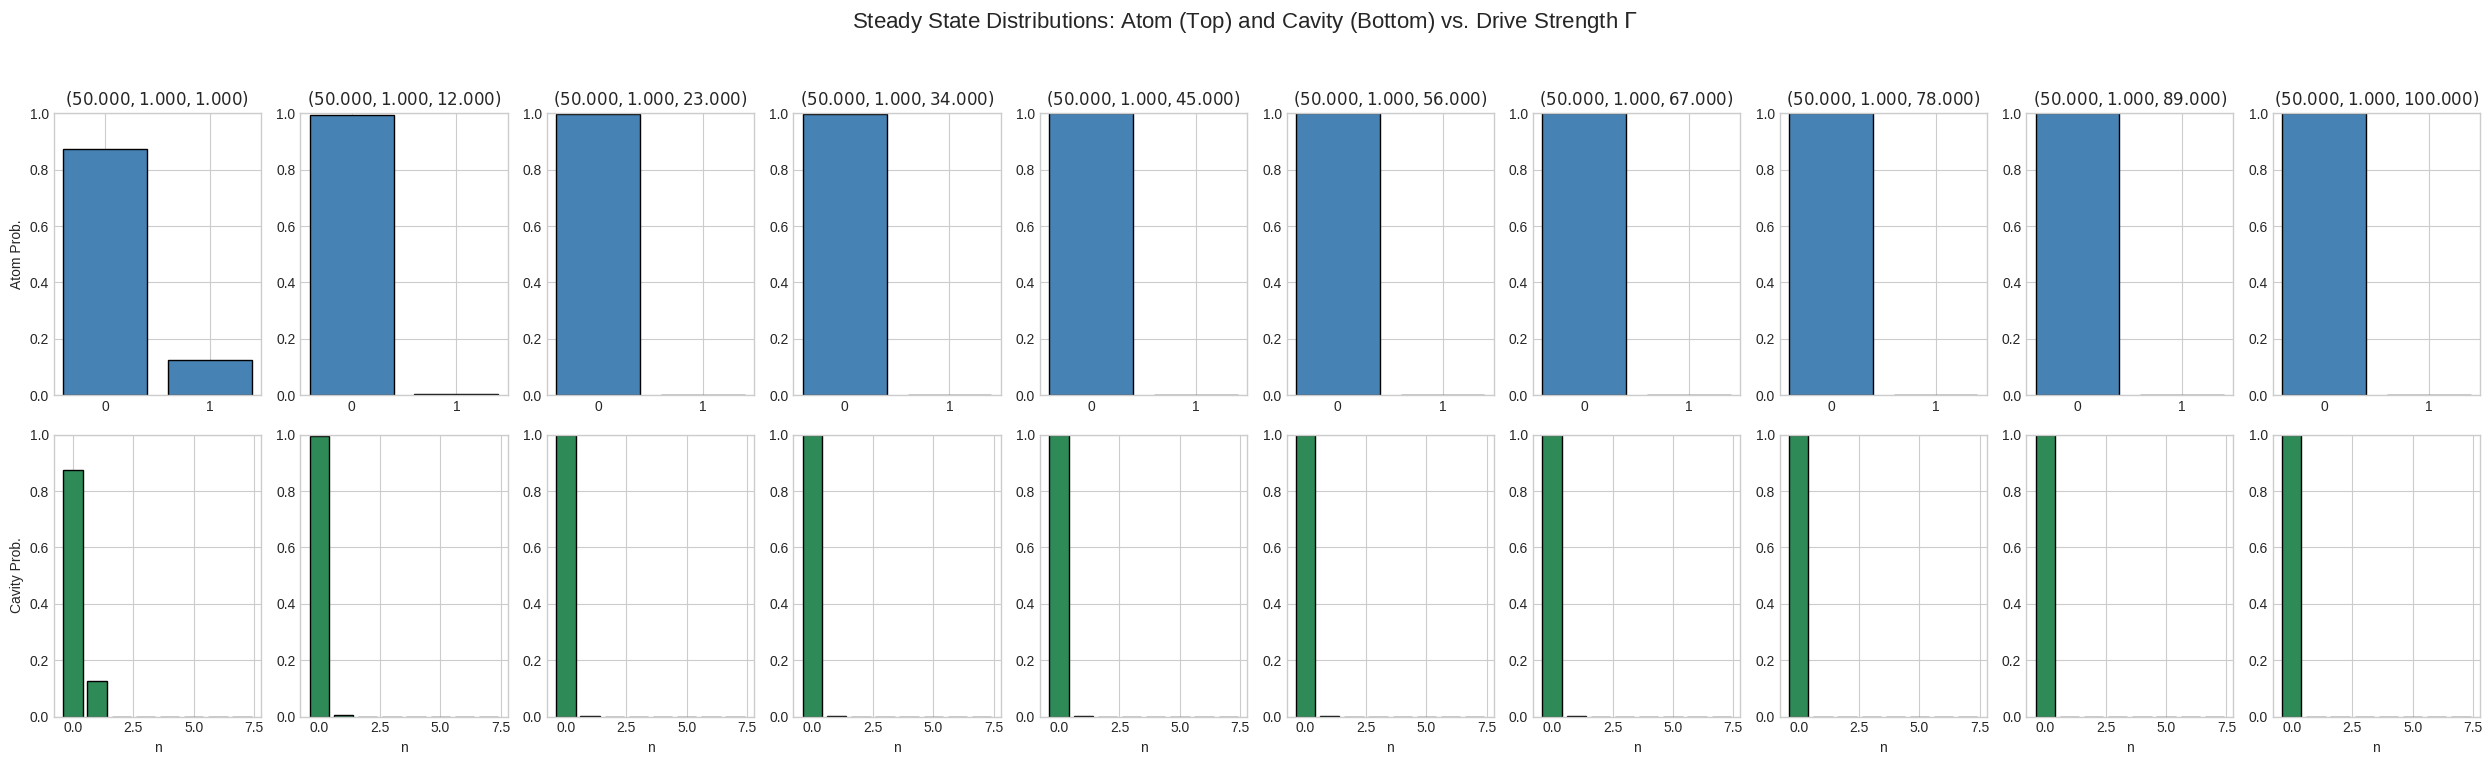

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# Parameters from your setup
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching
w_drive = wc - g # Resonant with the first dressed state

# Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))




# Setup Grid: 2 rows (Atom, Cavity) x 10 columns (E values)
fig, axes = plt.subplots(2, 10, figsize=(25, 8))
dc = wc - w_drive
da = wa - w_drive
for i, ga in enumerate(ga_values):
    # Hamiltonian in rotating frame at w_drive
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)
    c_ops = [np.sqrt(kappa) * a, np.sqrt(ga) * sm]
    # Calculate steady state
    rho_ss = qt.steadystate(H, c_ops)
    
    # 1. Atomic Distribution (Top Row)
    atom_dist = qt.ptrace(rho_ss, 1).diag().real
    axes[0, i].bar([0, 1], atom_dist, color='steelblue', edgecolor='black')
    axes[0, i].set_title(rf"$({g/kappa:.3f},{kappa/kappa:.3f},{ga/kappa:.3f})$")
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_xticks([0, 1])
    if i == 0: axes[0, i].set_ylabel("Atom Prob.")

    # 2. Cavity Fock Distribution (Bottom Row)
    cavity_dist = qt.ptrace(rho_ss, 0).diag().real
    axes[1, i].bar(range(8), cavity_dist[:8], color='seagreen', edgecolor='black')
    axes[1, i].set_ylim(0, 1)
    if i == 0: axes[1, i].set_ylabel("Cavity Prob.")
    axes[1, i].set_xlabel("n")

plt.suptitle(r"Steady State Distributions: Atom (Top) and Cavity (Bottom) vs. Drive Strength $\Gamma$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. A way to understand the suppression of two-photon states is to compute the two-photon correlation function $g^{(2)} \equiv \langle \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} \rangle / \langle \hat{a}^\dagger \hat{a} \rangle^2$, which compares the probability to find two simultaneous photons with the one of having two independent photons at random. In the blockade regime, you should find $g^{(2)} < 1$.

In [ ]:
import qutip as qt
import numpy as np

# 1. Parameters
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching

# 2. Identify the Resonance
# The lowest dressed states are at wc \pm g. 
# We set the drive frequency 'w' to the lower branch.
w = wc - g 

# 3. Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2)) # Note: sigmam is destroy(2)

# 4. Hamiltonian in the Rotating Frame (at drive frequency w)
dc = wc - w
da = wa - w

# H = Delta_c*a'a + Delta_a*sm'sm + g(a'sm + a*sm') + E(a + a')
Ht_0 = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)

# 5. Collapse Operators
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# 6. Find Steady State
rho_ss = qt.steadystate(Ht_0, c_ops)

# 7. Expectation Values
n_phot = qt.expect(a.dag() * a, rho_ss)
n_atom = qt.expect(sm.dag() * sm, rho_ss)
g2 = qt.expect(a.dag() * a.dag() * a * a, rho_ss) / (n_phot**2) if n_phot > 1e-9 else 0

print(f"Drive Frequency w: {np.abs(w) / (2*np.pi):.2f}")
print(f"Steady State Photon Number: {n_phot:.4f}")
print(f"Second-order correlation g(2)(0): {g2:.4f}")

Drive Frequency w: 0.99
Steady State Photon Number: 0.1252
Second-order correlation g(2)(0): 0.0072


In [ ]:
N = 20
hbar = 1
wc = 1.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching

# 2. Identify the Resonance
# The lowest dressed states are at wc \pm g. 
# We set the drive frequency 'w' to the lower branch.
w = wc - g 

# 3. Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2)) # Note: sigmam is destroy(2)

# 4. Hamiltonian in the Rotating Frame (at drive frequency w)
dc = wc - w
da = wa - w

# H = Delta_c*a'a + Delta_a*sm'sm + g(a'sm + a*sm') + E(a + a')
Ht_0 = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a)

# 5. Collapse Operators
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]




output = qt.mesolve(Ht_0, psi0, tlist, c_op_list, e_ops =[a.dag() * a, sm.dag() * sm, a.dag() * a.dag() * a* a], options={"store_states": True, "nsteps": 10000, "atol": 1e-8, "rtol": 1e-6})

n_phot = output.expect[0][-1]
g2 = output.expect[2][-1] / (n_phot**2) if n_phot > 1e-9 else 0
print(f"Drive Frequency w: {np.abs(w) / (2*np.pi):.2f}")
print(f"Steady State Photon Number: {n_phot:.4f}")
print(f"Second-order correlation g(2)(0): {g2:.4f}")

Drive Frequency w: 0.99
Steady State Photon Number: 0.1286
Second-order correlation g(2)(0): 0.0070


## 7. Scan the values of $\omega$ around the resonance and graphically represent your findings as in Fig. 2a of the paper by Birnbaum et al.

In [320]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters (Birnbaum-like Strong Coupling)
N = 20
hbar = 1
wc = 2.0 * 2 * np.pi
wa = 1.0 * 2 * np.pi
kappa = 0.001 #2 * np.pi  # cavity dissipation rate
gamma = 0.001 #2 * np.pi  # atom dissipation rate
g = 100*max(gamma,kappa) #*100  # coupling strength
E = 0.0005 # Reduced slightly to ensure deep antibunching

# 2. Setup Operators
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sm = qt.tensor(qt.qeye(N), qt.destroy(2))
c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

# 3. Frequency Scan Range (Centered around wc)
# Scanning from -1.5g to 1.5g to capture the peaks
w_list = np.linspace(wc - 1.5*g, wc + 1.5*g, 200)
n_ss = []
g2_ss = []

for w in w_list:
    dc = wc - w
    da = wa - w
    # Standard Jaynes-Cummings Hamiltonian in the rotating frame
    H = hbar*dc*a.dag()*a + hbar*da*sm.dag()*sm + hbar*g*(sm.dag()*a ) + hbar*g*( sm*a.dag()) + E*(a.dag() + a) #dc*a.dag()*a + da*sm.dag()*sm + g*(a.dag()*sm + a*sm.dag()) + E*(a.dag() + a)
    
    rho_ss = qt.steadystate(H, c_ops)
    
    n = qt.expect(a.dag() * a, rho_ss)
    n_ss.append(n)
    
    # Calculate g2(0)
    g2 = qt.expect(a.dag()*a.dag()*a*a, rho_ss) / (n**2) if n > 1e-9 else 1
    g2_ss.append(g2)



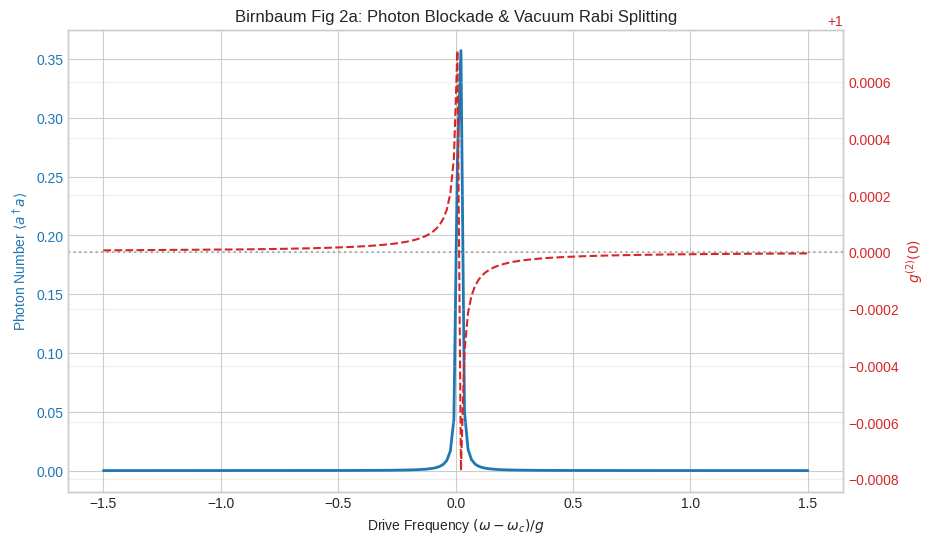

In [321]:
# 4. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel(r'Drive Frequency $(\omega - \omega_c)/g$')
ax1.set_ylabel(r'Photon Number $\langle a^\dagger a \rangle$', color=color)
# Note the division by g to normalize the x-axis
ax1.plot((w_list - wc)/g, n_ss, color=color, lw=2, label='Transmission')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel(r'$g^{(2)}(0)$', color=color)
ax2.plot((w_list - wc)/g, g2_ss, color=color, linestyle='--', label='$g^{(2)}(0)$')
ax2.axhline(1.0, color='black', alpha=0.3, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Birnbaum Fig 2a: Photon Blockade & Vacuum Rabi Splitting")
plt.grid(alpha=0.3)
plt.show()

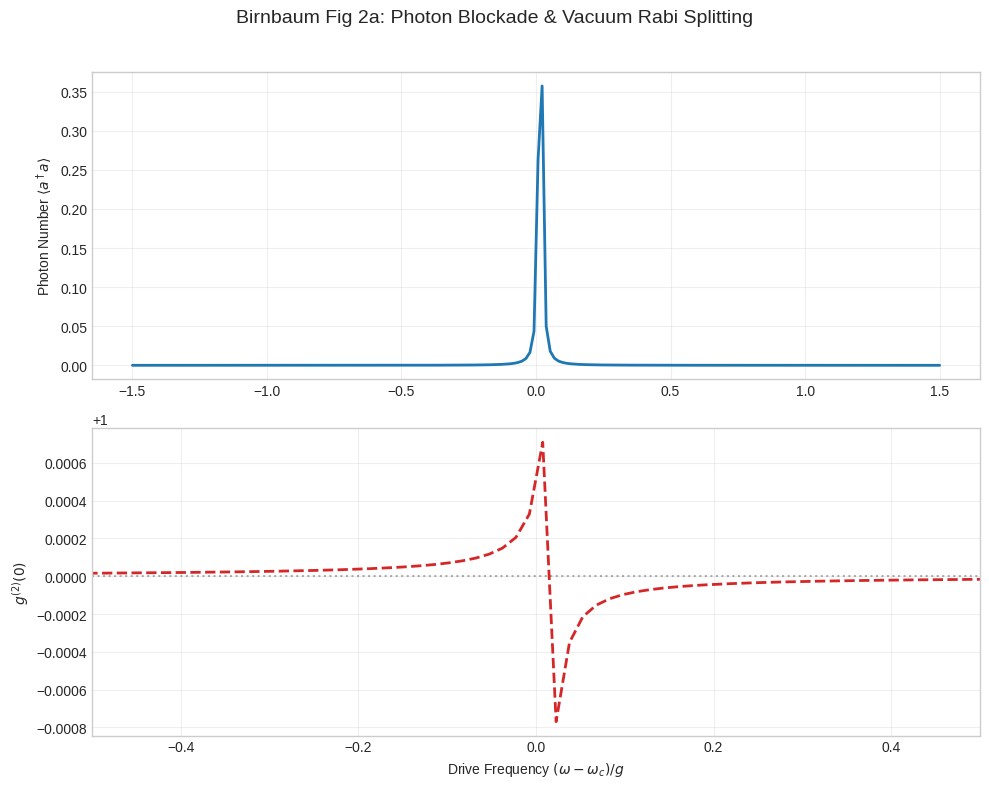

In [322]:
# 4. Plotting: 1 column, 2 rows
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 8),
    sharex=False
)

x = (w_list - wc) / g

# ---- Top panel: Photon number ----
ax1.plot(x, n_ss, color='tab:blue', lw=2)
ax1.set_ylabel(r'Photon Number $\langle a^\dagger a \rangle$')
ax1.grid(alpha=0.3)

# ---- Bottom panel: g^(2)(0) ----
ax2.plot(x, g2_ss, color='tab:red', lw=2, linestyle='--')
ax2.axhline(1.0, color='black', alpha=0.3, linestyle=':')
ax2.set_xlabel(r'Drive Frequency $(\omega - \omega_c)/g$')
ax2.set_ylabel(r'$g^{(2)}(0)$')
ax2.grid(alpha=0.3)
ax2.set_xlim(-0.5, 0.5)

# ---- Title ----
fig.suptitle("Birnbaum Fig 2a: Photon Blockade & Vacuum Rabi Splitting", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 8. (Bonus) Can you make analytical predictions for the steady state in a convenient regime?